In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


RSEED = 202344 
np.random.seed(RSEED)

import sys
# REDACTED: Add your project path here
# sys.path.append('/path/to/your/project')

from data_loading import fetch_query_with_progress

import psycopg2
from tqdm import tqdm

# REDACTED: Load credentials from environment or secure config
# Read from environment: password = os.getenv('DB_PASSWORD')
password = "PULL_CREDENTIALS_HERE"  # Use environment variables or secrets manager


## Query

In [ ]:
number_of_users = 60000

# REDACTED: Replace with your actual database query
query = f"""
WITH sampled_user_ids AS (
    SELECT DISTINCT user_id
    FROM [YOUR_SCHEMA].[transactions_table]
    WHERE user_id IS NOT NULL
      AND created_at >= DATE '2022-01-01'
    ORDER BY RANDOM()
    LIMIT {number_of_users}
),
transactions_filtered AS (
    SELECT *
    FROM [YOUR_SCHEMA].[transactions_table]
    WHERE created_at >= DATE '2022-01-01'
      AND user_id IN (SELECT user_id FROM sampled_user_ids)
)
SELECT 
    t.*, 
    u.*
FROM transactions_filtered t
LEFT JOIN [YOUR_SCHEMA].[users_table] u
    ON t.user_id = u.id;

"""


## Pull Data

In [ ]:
# REDACTED: Database connection with credentials
# Connect to your database (e.g., Redshift, PostgreSQL, etc.)

import os

# Load credentials from environment variables (recommended for security)
db_host = os.getenv('DB_HOST', 'your-database-host.redshift.amazonaws.com')
db_port = int(os.getenv('DB_PORT', '5439'))
db_name = os.getenv('DB_NAME', 'your_database')
db_user = os.getenv('DB_USER', 'your_username')
db_password = os.getenv('DB_PASSWORD', 'PULL_CREDENTIALS_HERE')

conn = psycopg2.connect(
    host=db_host,
    port=db_port,
    database=db_name,
    user=db_user,
    password=db_password
)

df = fetch_query_with_progress(
    conn=conn,
    query=query,
    chunk_size=1000,
    save_path="transactions.pkl"
)


📁 Loading existing data from pass_rides.pkl


In [ ]:
# REDACTED: Select relevant columns for analysis
# Replace column names with your actual data columns
data = df[['passenger_id', 'ride_request_id',  'booking_request_id', 'country_name', 'city_id', 'product_id', 
    'state', 'cancel_reason', 'multiplier', 
    'is_painful_cancellation', 'pre_ride_duration', 'user_account_created_at',
    'first_ride_request_date', 'last_ride_request_date', 'spent_amount_sum_all_time', 
    'created_at_business_night', 'total_price', 'estimated_duration', 'created_at_local_time',
    'payment_mode', 'total_estimated_price', 'estimated_distance', 'currency', 'passenger_os_name',
    'stopover_count', 'coupons_entries_count', 'passenger_app_version',
    ]]
# NOTE: Ensure no PII or proprietary identifiers are included in your public version


# Var Creation

Creates new columns in data for:
- Region (Europe/Africa)
- Ride state (terminated)
- Day/time features (day of week, is Friday/weekend, etc.)
- Cumulative and rolling features (proportions, averages)
- Payment mode, OS, app version, etc.
- Time on platform, days between rides, rolling price, etc.
- Purpose:

Transforms raw ride-level data into engineered features that capture user behavior and context.

In [ ]:
# --- Feature Engineering (Var Creation) ---
cols_made = []

# Region Features - REDACTED: Replace with your own region definitions
data['region_group_1'] = data['country_name'].isin([
    'COUNTRY_A', 'COUNTRY_B', 'COUNTRY_C', 'COUNTRY_D'
]).astype(int)
cols_made.append('region_group_1')

data['region_group_2'] = data['country_name'].isin([
    'COUNTRY_E', 'COUNTRY_F', 'COUNTRY_G', 'COUNTRY_H', 'COUNTRY_I', 'COUNTRY_J', 'COUNTRY_K', 'COUNTRY_L'
]).astype(int)
cols_made.append('region_group_2')

# Terminated Feature
data['terminated'] = (data['state'] == 'terminated').astype(int)
cols_made.append('terminated')

# Day/Time Features
data['day_of_week'] = data['created_at_local_time'].dt.dayofweek
data['is_friday'] = (data['day_of_week'] == 4).astype(int)
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)
data['is_weekday'] = data['day_of_week'].isin([0, 1, 2, 3]).astype(int)
data['is_friday_or_weekend'] = (data['is_friday'] | data['is_weekend']).astype(int)

# Cumulative Friday/weekend proportion (excluding current)
data['cum_fw'] = data.groupby('passenger_id')['is_friday_or_weekend'].cumsum().shift(1)
data['cum_total'] = data.groupby('passenger_id').cumcount()
data['prop_friday_or_weekend'] = (data['cum_fw'] / data['cum_total']).replace([np.inf, -np.inf], 0).fillna(0)
cols_made.append('prop_friday_or_weekend')
data.drop(columns=['cum_fw', 'cum_total'], inplace=True)

# Cumulative evening proportion (excluding current)
data['is_evening'] = (data['created_at_local_time'].dt.hour >= 18).astype(int)
data['cum_evening'] = data.groupby('passenger_id')['is_evening'].cumsum().shift(1)
data['cum_total_rides'] = data.groupby('passenger_id').cumcount()
data['prop_evening'] = (data['cum_evening'] / data['cum_total_rides']).replace([np.inf, -np.inf], 0).fillna(0)
cols_made.append('prop_evening')
data.drop(columns=['cum_evening', 'cum_total_rides'], inplace=True)

# Cash Feature
data['cash'] = (data['payment_mode'] == 'cash').astype(int)
cols_made.append('cash')

# iOS Feature
data['ios'] = (data['passenger_os_name'] == 'iOS').astype(int)
cols_made.append('ios')

#city
# Ever in more than one city (user-level flag)
ever_multicity = (
    data.groupby('passenger_id')['city_id']
    .nunique()
    .gt(1)
    .astype(int)
    .rename('ever_multicity_user')
)

data = data.merge(ever_multicity, on='passenger_id', how='left')


# Time on Platform (in days, aligned to week)
first_ride_date = data.groupby('passenger_id')['created_at_local_time'].min()
data['week'] = data['created_at_local_time'].dt.to_period('W-MON').dt.start_time
data['length_of_time_on_plat'] = (data['week'] - data['passenger_id'].map(first_ride_date)).dt.days.clip(lower=0)
cols_made.append('length_of_time_on_plat')

# Days Between Rides (terminated only, running average)
data = data.sort_values(['passenger_id', 'created_at_local_time'])
data['previous_ride_time'] = data.groupby('passenger_id')['created_at_local_time'].shift(1)
data['days_since_last_ride'] = (data['created_at_local_time'] - data['previous_ride_time']).dt.days.fillna(0).astype(int)
data['weeks_since_last_ride'] = data['days_since_last_ride'] / 7.0
data['masked_days'] = data['days_since_last_ride'].where(data['terminated'] == 1)
data['cum_sum_days'] = data.groupby('passenger_id')['masked_days'].cumsum().shift(1)
data['cum_count_days'] = data.groupby('passenger_id')['masked_days'].transform(lambda x: x.notna().cumsum().shift(1))
data['avg_days_between_rides'] = (data['cum_sum_days'] / data['cum_count_days']).fillna(0)
first_valid_idx = data[data['terminated'] == 1].groupby('passenger_id').head(1).index
data.loc[first_valid_idx, 'avg_days_between_rides'] = 0
cols_made.append('avg_days_between_rides')
data.drop(columns=['previous_ride_time', 'masked_days', 'cum_sum_days', 'cum_count_days'], inplace=True)

# App Version Numeric
def version_to_float(v):
    try:
        major, minor, patch = map(int, v.split('.'))
        return major * 1_000 + minor * 10 + patch
    except Exception:
        return np.nan
data['app_version_numeric'] = data['passenger_app_version'].apply(version_to_float) / 1000
cols_made.append('app_version_numeric')

# Rolling Average Price 
# Ensure total_price is numeric
# Ensure numeric price
data['total_price'] = pd.to_numeric(data['total_price'], errors='coerce')

# Sort data first
data = data.sort_values(['passenger_id', 'created_at_local_time'])


/var/folders/sg/dlx6wk_d10j2850gg13k224h0000gp/T/ipykernel_73675/3349075073.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Europe'] = data['country_name'].isin([
/var/folders/sg/dlx6wk_d10j2850gg13k224h0000gp/T/ipykernel_73675/3349075073.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Africa'] = data['country_name'].isin([
/var/folders/sg/dlx6wk_d10j2850gg13k224h0000gp/T/ipykernel_73675/3349075073.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

# Weekly aggragation 

- Builds a dense (user, week) grid for each user's observed period.
- Merges in your weekly aggregates.
- Fills any_terminated as 0 for inactive weeks.
- Leaves other features as NaN (or you can choose your own fill strategy).
- Prepares weekly_data for HMM input.
- Let me know if you want to customize the NaN filling strategy for other features!

Purpose:

Creates a weekly, user-level dataset (weekly_data) suitable for time series modeling (like HMM), with one row per user per week.

                                week           dead          cash  \
count                         204694  204694.000000  66706.000000   
mean   2023-10-16 01:34:21.117570304       0.021623      0.502541   
min              2021-12-28 00:00:00       0.000000      0.000000   
25%              2022-12-06 00:00:00       0.000000      0.000000   
50%              2023-10-31 00:00:00       0.000000      0.500000   
75%              2024-08-20 00:00:00       0.000000      1.000000   
max              2025-07-15 00:00:00       1.000000      1.000000   
std                              NaN       0.145448      0.487227   

                ios  terminated_rides  app_version_numeric  \
count  66706.000000      66706.000000         66706.000000   
mean       0.688083          1.535049             6.126187   
min        0.000000          0.000000             4.350000   
25%        0.000000          1.000000             5.620000   
50%        1.000000          1.000000             5.870000   
75%   

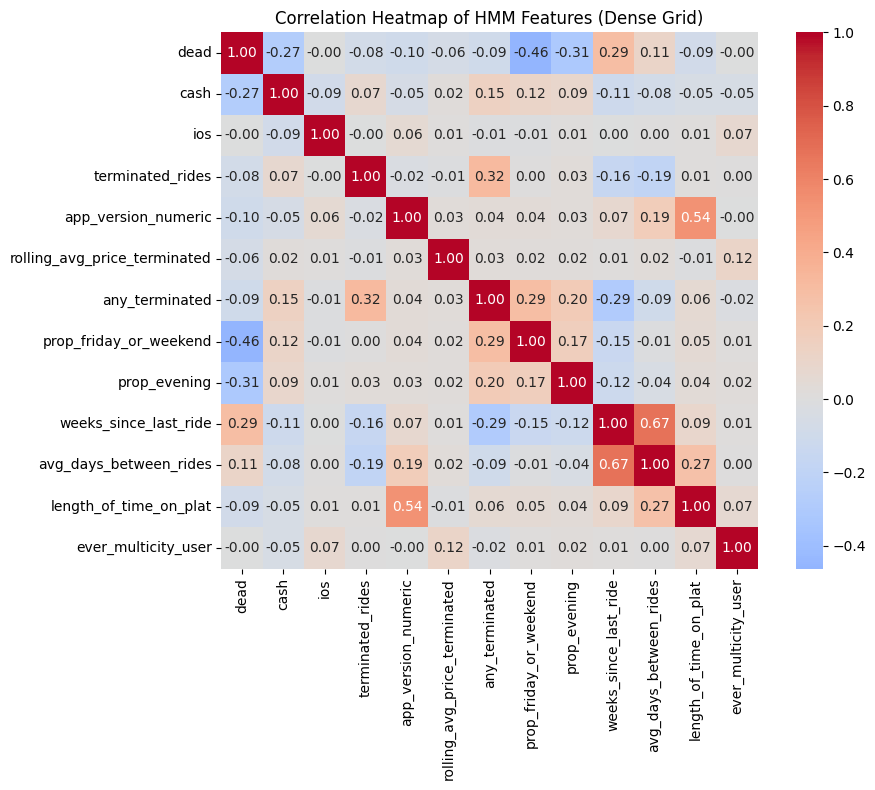

In [ ]:
### consider alligning iwth growth model!!!!
max_gap_weeks = 19  # <-- set your cutoff manually here
#19 is 127 / 7 rounded up to the nearest week. 

# REDACTED: Filter for your region of interest
# Replace 'region_group_1' with your desired region column
data = data.loc[data['region_group_1'] == 1]

# 1. Ensure 'week' is set correctly
data['week'] = data['created_at_local_time'].dt.to_period('W-MON').dt.start_time

# 2. Per-ride binary features
data['is_friday_or_weekend'] = data['created_at_local_time'].dt.dayofweek.isin([4, 5, 6]).astype(int)
data['is_evening'] = (data['created_at_local_time'].dt.hour >= 18).astype(int)
data['is_cash'] = (data['payment_mode'] == 'cash').astype(int)
data['is_ios'] = (data['passenger_os_name'] == 'iOS').astype(int)
data['is_terminated'] = (data['state'] == 'terminated').astype(int)

# 3. Compute each user's first ride date
first_ride = data.groupby('passenger_id')['created_at_local_time'].min()


In [7]:
features_to_ffill = [
    'prop_friday_or_weekend',
    'prop_evening',
    'avg_days_between_rides',
    'app_version_numeric',
    'rolling_avg_price_terminated',
    'ios'
]

# Forward-fill each feature per user (real data points are never overwritten)
weekly_data[features_to_ffill] = (
    weekly_data.groupby('passenger_id')[features_to_ffill].ffill()
)

# (Optional) Check for remaining NaNs in these columns
print(weekly_data[features_to_ffill].isnull().sum())
print("rolling_avg_price_terminated as null means the person never took a ride")

prop_friday_or_weekend              0
prop_evening                        0
avg_days_between_rides          30942
app_version_numeric                 0
rolling_avg_price_terminated     3324
ios                                 0
dtype: int64
rolling_avg_price_terminated as null means the person never took a ride


In [8]:
weekly_data.head(30)

,passenger_id,week,dead,cash,ios,terminated_rides,app_version_numeric,rolling_avg_price_terminated,any_terminated,prop_friday_or_weekend,prop_evening,weeks_since_last_ride,avg_days_between_rides,length_of_time_on_plat,ever_multicity_user
0,0004d343-e619-4648-b75e-8f7bda5236cd,2021-12-28,0,1.000000,1.0,1.0,5.4100,8.000000,1.0,1.000000,0.000000,NaN,NaN,0.0,0
1,0004d343-e619-4648-b75e-8f7bda5236cd,2022-01-04,0,0.000000,1.0,3.0,5.4100,8.000000,1.0,0.500000,0.250000,1.0,1.750000,7.0,0
2,0004d343-e619-4648-b75e-8f7bda5236cd,2022-01-11,0,0.000000,1.0,1.0,5.4100,8.300000,1.0,0.500000,0.500000,1.0,2.800000,14.0,0
3,0004d343-e619-4648-b75e-8f7bda5236cd,2022-01-18,0,0.000000,1.0,2.0,5.4100,8.464286,1.0,0.500000,0.500000,1.0,3.000000,21.0,0
4,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-03-14,0,0.250000,0.0,4.0,5.7200,12.937500,1.0,0.250000,0.000000,NaN,NaN,0.0,0
5,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-03-21,0,0.500000,0.0,2.0,5.7200,15.783333,1.0,0.333333,0.000000,1.0,1.166667,7.0,0
6,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-03-28,0,0.800000,0.0,3.0,5.7288,18.892857,1.0,0.636364,0.181818,1.0,1.555556,14.0,0
7,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-04-04,0,0.000000,0.0,4.0,5.7400,17.957139,1.0,0.533333,0.133333,1.0,1.615385,21.0,0
8,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-04-11,0,0.500000,0.0,1.0,5.7400,19.013736,1.0,0.470588,0.117647,1.0,2.000000,28.0,0
9,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-04-18,0,NaN,0.0,NaN,5.7400,19.013736,0.0,0.470588,0.117647,NaN,2.000000,NaN,0


In [9]:
#rolling_avg_price_terminated as null means the person never took a ride
weekly_data = weekly_data.loc[weekly_data['rolling_avg_price_terminated'].isna() == False]

In [10]:
print("Any NaNs?", weekly_data.isnull().any().any())
print("Any Infs?", np.isinf(weekly_data.select_dtypes(include=[np.number])).any().any())

Any NaNs? True
Any Infs? False


In [11]:
# counts still keep going
def ffill_with_increment(series, increment):
    """
    Forward-fill a series, adding 'increment' to the previous value for each NaN.
    """
    result = series.copy()
    for i in range(1, len(result)):
        if pd.isna(result.iloc[i]):
            result.iloc[i] = result.iloc[i-1] + increment
    return result

# For length_of_time_on_plat (add 7 days per missing week)
weekly_data['length_of_time_on_plat'] = (
    weekly_data.groupby('passenger_id')['length_of_time_on_plat']
    .apply(lambda x: ffill_with_increment(x, 7))
    .reset_index(level=0, drop=True)
)

# For weeks_since_last_ride (add 1 week per missing week)
weekly_data['weeks_since_last_ride'] = (
    weekly_data.groupby('passenger_id')['weeks_since_last_ride']
    .apply(lambda x: ffill_with_increment(x, 1))
    .reset_index(level=0, drop=True)
)

# ddCheck for remaining NaNs
print("NaNs in length_of_time_on_plat:", weekly_data['length_of_time_on_plat'].isnull().sum())
print("NaNs in weeks_since_last_ride:", weekly_data['weeks_since_last_ride'].isnull().sum())

NaNs in length_of_time_on_plat: 0
NaNs in weeks_since_last_ride: 25004


In [12]:
#cash and cities are fine as zero
weekly_data['cash'].replace(np.nan, 0, inplace=True)
weekly_data['ever_multicity_user'].value_counts()

/var/folders/sg/dlx6wk_d10j2850gg13k224h0000gp/T/ipykernel_73675/3079263118.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weekly_data['cash'].replace(np.nan, 0, inplace=True)


ever_multicity_user
0    164406
1     36964
Name: count, dtype: int64

In [13]:
weekly_data.isna().sum()

passenger_id                         0
week                                 0
dead                                 0
cash                                 0
ios                                  0
terminated_rides                135682
app_version_numeric                  0
rolling_avg_price_terminated         0
any_terminated                       0
prop_friday_or_weekend               0
prop_evening                         0
weeks_since_last_ride            25004
avg_days_between_rides           27618
length_of_time_on_plat               0
ever_multicity_user                  0
dtype: int64

In [14]:
# avg_days_between_rides - NOT working, but not used lower down. 
weekly_data.head(15)

,passenger_id,week,dead,cash,ios,terminated_rides,app_version_numeric,rolling_avg_price_terminated,any_terminated,prop_friday_or_weekend,prop_evening,weeks_since_last_ride,avg_days_between_rides,length_of_time_on_plat,ever_multicity_user
0,0004d343-e619-4648-b75e-8f7bda5236cd,2021-12-28,0,1.00,1.0,1.0,5.4100,8.000000,1.0,1.000000,0.000000,NaN,NaN,0.0,0
1,0004d343-e619-4648-b75e-8f7bda5236cd,2022-01-04,0,0.00,1.0,3.0,5.4100,8.000000,1.0,0.500000,0.250000,1.0,1.750000,7.0,0
2,0004d343-e619-4648-b75e-8f7bda5236cd,2022-01-11,0,0.00,1.0,1.0,5.4100,8.300000,1.0,0.500000,0.500000,1.0,2.800000,14.0,0
3,0004d343-e619-4648-b75e-8f7bda5236cd,2022-01-18,0,0.00,1.0,2.0,5.4100,8.464286,1.0,0.500000,0.500000,1.0,3.000000,21.0,0
4,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-03-14,0,0.25,0.0,4.0,5.7200,12.937500,1.0,0.250000,0.000000,NaN,NaN,0.0,0
5,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-03-21,0,0.50,0.0,2.0,5.7200,15.783333,1.0,0.333333,0.000000,1.0,1.166667,7.0,0
6,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-03-28,0,0.80,0.0,3.0,5.7288,18.892857,1.0,0.636364,0.181818,1.0,1.555556,14.0,0
7,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-04-04,0,0.00,0.0,4.0,5.7400,17.957139,1.0,0.533333,0.133333,1.0,1.615385,21.0,0
8,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-04-11,0,0.50,0.0,1.0,5.7400,19.013736,1.0,0.470588,0.117647,1.0,2.000000,28.0,0
9,0007a54f-8420-43bc-bafe-9b44145ee75d,2023-04-18,0,0.00,0.0,NaN,5.7400,19.013736,0.0,0.470588,0.117647,2.0,2.000000,35.0,0


In [15]:
# Validation of the new calculations
print("=== Validation of Weekly Metrics ===")

# Check proportions are between 0 and 1
print("\nProportion ranges:")
print("prop_friday_or_weekend range:", weekly_data['prop_friday_or_weekend'].min(), "to", weekly_data['prop_friday_or_weekend'].max())
print("prop_evening range:", weekly_data['prop_evening'].min(), "to", weekly_data['prop_evening'].max())

# Check avg_days_between_rides makes sense
print("\nAvg days between rides stats:")
print(weekly_data['avg_days_between_rides'].describe())

# Check weeks_since_last_ride progression
sample_user = weekly_data.groupby('passenger_id').filter(lambda x: len(x) >= 5).iloc[0]['passenger_id']
print(f"\nSample progression for user {sample_user}:")
sample_data = weekly_data[weekly_data['passenger_id'] == sample_user].head(5)
print(sample_data[['week', 'any_terminated', 'weeks_since_last_ride', 'avg_days_between_rides']])

=== Validation of Weekly Metrics ===

Proportion ranges:
prop_friday_or_weekend range: 0.0 to 1.0
prop_evening range: 0.0 to 1.0

Avg days between rides stats:
count    173752.000000
mean         32.106965
std          37.843095
min           0.200000
25%           9.586957
50%          20.125000
75%          40.444444
max         605.500000
Name: avg_days_between_rides, dtype: float64

Sample progression for user 0007a54f-8420-43bc-bafe-9b44145ee75d:
        week  any_terminated  weeks_since_last_ride  avg_days_between_rides
4 2023-03-14             1.0                    NaN                     NaN
5 2023-03-21             1.0                    1.0                1.166667
6 2023-03-28             1.0                    1.0                1.555556
7 2023-04-04             1.0                    1.0                1.615385
8 2023-04-11             1.0                    1.0                2.000000


In [16]:
user_avg = (
    weekly_data
    .groupby("passenger_id", as_index=False)["prop_friday_or_weekend"]
    .mean()
    .rename(columns={"prop_friday_or_weekend": "avg_weekend_prop"})
)

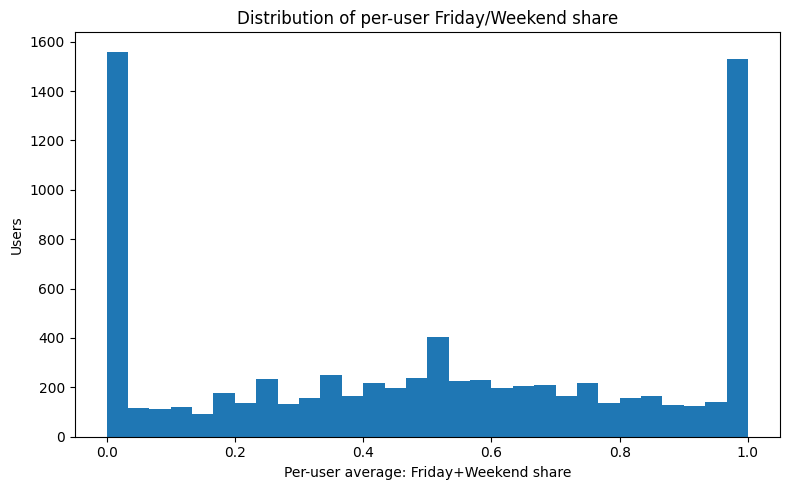

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(user_avg["avg_weekend_prop"], bins=30)
plt.xlabel("Per-user average: Friday+Weekend share")
plt.ylabel("Users")
plt.title("Distribution of per-user Friday/Weekend share")
plt.tight_layout()
plt.show()

# Scaling 
- Defines the list of features to use for HMM.
- Identifies which features to scale (numeric, non-binary).
- Scales those features using StandardScaler.
- Combines scaled and unscaled features into X_final.
- Checks for missing columns and prints a summary.

Purpose:

Prepares the feature matrix for HMM modeling, ensuring all features are on comparable scales.

In [18]:
weekly_data['weeks_since_last_ride_log'] = np.log(weekly_data['weeks_since_last_ride'] + 1 )
weekly_data['rolling_avg_price_terminated_log'] = np.log(weekly_data['rolling_avg_price_terminated'] + 1)

In [19]:
from sklearn.preprocessing import StandardScaler

# 1. Define your HMM features (excluding identifiers)
features_hmm = [
    'prop_friday_or_weekend',
    #'prop_evening',
    'cash',
    'ios',
    #'length_of_time_on_plat',
    #'avg_days_between_rides',
    'weeks_since_last_ride_log',
    #'app_version_numeric',
    'rolling_avg_price_terminated_log',
    'ever_multicity_user',
    'any_terminated'
]

# 2. Identify which features to scale (exclude binary/categorical)
features_to_scale = [
    'prop_friday_or_weekend',
    #'prop_evening',
    #'length_of_time_on_plat',
    #'avg_days_between_rides',
    'weeks_since_last_ride_log',
    #'app_version_numeric',
    'rolling_avg_price_terminated_log',
]


# 3. Prepare data for scaling (drop rows with NaN in features to scale)
X = weekly_data[features_hmm].dropna(subset=features_to_scale).copy()

# 4. Scale
scaler = StandardScaler()
X_scaled_part = pd.DataFrame(
    scaler.fit_transform(X[features_to_scale]),
    columns=features_to_scale,
    index=X.index
)

# 5. Combine scaled and unscaled (all remaining columns)
X_unscaled = X.drop(columns=features_to_scale)
X_final = pd.concat([X_scaled_part, X_unscaled], axis=1)

# 6. Ensure column order matches features_hmm
X_final = X_final[features_hmm]

# 7. (Optional) Check for missing columns
missing = [col for col in features_hmm if col not in X_final.columns]
if missing:
    print("Missing columns:", missing)

# 8. (Optional) Print summary
X_final.describe()

,prop_friday_or_weekend,cash,ios,weeks_since_last_ride_log,rolling_avg_price_terminated_log,ever_multicity_user,any_terminated
count,1.763660e+05,176366.000000,176366.000000,1.763660e+05,1.763660e+05,176366.000000,176366.000000
mean,-6.720033e-17,0.162615,0.693650,5.878820e-16,-6.615284e-17,0.189311,0.280808
std,1.000003e+00,0.362948,0.460906,1.000003e+00,1.000003e+00,0.391756,0.449395
min,-2.168677e+00,0.000000,0.000000,-1.575376e+00,-4.663765e+00,0.000000,0.000000
25%,-5.960254e-01,0.000000,0.000000,-8.083246e-01,-2.769204e-01,0.000000,0.000000
50%,6.266804e-03,0.000000,1.000000,-4.127288e-02,3.971437e-02,0.000000,0.000000
75%,6.424380e-01,0.000000,1.000000,7.257788e-01,3.826772e-01,0.000000,1.000000
max,1.920218e+00,1.000000,1.000000,3.366694e+00,9.402523e+00,1.000000,1.000000


In [20]:
# Align both DataFrames by resetting their indices
X_final = X_final.reset_index(drop=True)
weekly_data = weekly_data.reset_index(drop=True)

# Now you can safely assign the columns
X_final['passenger_id'] = weekly_data['passenger_id']
X_final['week'] = weekly_data['week']

# Sort by passenger and week
X_final = X_final.sort_values(['passenger_id', 'week']).reset_index(drop=True)

# Observation matrix (N x D)
X_obs = X_final[features_hmm].values

# Sequence lengths (number of weeks per passenger)
lengths = X_final.groupby('passenger_id').size().tolist()

In [21]:
# Inspect variation and summary stats for all HMM features

print("=== HMM Feature Diagnostics ===")
for col in features_hmm:
    print(f"\n--- {col} ---")
    if col not in weekly_data.columns:
        print("  [Column missing!]")
        continue
    unique_vals = weekly_data[col].unique()
    nunique = weekly_data[col].nunique()
    print(f"  Number of unique values: {nunique}")
    print(f"  First 10 unique values: {unique_vals[:10]}")
    print("  Describe:")
    print(weekly_data[col].describe())
    # For categorical/binary, show value counts
    if nunique <= 10:
        print("  Value counts:")
        print(weekly_data[col].value_counts())
print("\n=== End of Diagnostics ===")

=== HMM Feature Diagnostics ===

--- prop_friday_or_weekend ---
  Number of unique values: 4951
  First 10 unique values: [1.         0.5        0.25       0.33333333 0.63636364 0.53333333
 0.47058824 0.44444444 0.38095238 0.36363636]
  Describe:
count    201370.000000
mean          0.535213
std           0.281884
min           0.000000
25%           0.363636
50%           0.535714
75%           0.714286
max           1.000000
Name: prop_friday_or_weekend, dtype: float64

--- cash ---
  Number of unique values: 85
  First 10 unique values: [1.         0.         0.25       0.5        0.8        0.77777778
 0.33333333 0.83333333 0.2        0.66666667]
  Describe:
count    201370.000000
mean          0.163128
std           0.363797
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: cash, dtype: float64

--- ios ---
  Number of unique values: 20
  First 10 unique values: [1.         0.         0.5        0.66666667 0.75

# THe HMM

In [22]:
from hmmlearn.hmm import GaussianHMM
NUMBER_OF_STATES = 9


# 1. Add identifiers for sequence grouping
X_final['passenger_id'] = weekly_data.loc[X_final.index, 'passenger_id']
X_final['week'] = weekly_data.loc[X_final.index, 'week']

# 2. Sort by passenger and week
X_final = X_final.sort_values(['passenger_id', 'week']).reset_index(drop=True)

# 3. Observation matrix (N x D)
X_obs = X_final[features_hmm].values

# 4. Sequence lengths (number of weeks per passenger)
lengths = X_final.groupby('passenger_id').size().tolist()

# 5. Fit the HMM
n_states = NUMBER_OF_STATES  # You can tune this
random_seed = RSEED

model = GaussianHMM(
    n_components=n_states,
    covariance_type='diag',
    n_iter=500,
    random_state=random_seed
)

model.fit(X_obs, lengths)

# 6. Decode the latent states
hidden_states = model.predict(X_obs, lengths)
X_final['hmm_state'] = hidden_states

# 7. Most frequent state per passenger
passenger_state_counts = (
    X_final.groupby(['passenger_id', 'hmm_state'])
          .size()
          .unstack(fill_value=0)
)
dominant_states = passenger_state_counts.idxmax(axis=1)
state_counts = dominant_states.value_counts().sort_index()

print("\nNumber of passengers assigned to each dominant latent state:")
for state, count in state_counts.items():
    print(f"State {state}: {count} passengers")

# 8. State means
state_means_df = (
    X_final
      .groupby('hmm_state')[features_hmm]
      .mean()
      .reset_index()
)
print("\nMean feature values by HMM state:")
print(state_means_df)

# 9. Transition matrix
state_labels = [f"State {i}" for i in range(n_states)]
trans_df = pd.DataFrame(model.transmat_, index=state_labels, columns=state_labels)
print("\nTransition probabilities DataFrame (A):")
print(trans_df)

Model is not converging.  Current: 2414781.386342197 is not greater than 2414781.386447868. Delta is -0.00010567065328359604



Number of passengers assigned to each dominant latent state:
State 0: 104 passengers
State 2: 329 passengers
State 3: 4717 passengers
State 4: 672 passengers
State 5: 29 passengers
State 6: 257 passengers
State 7: 1061 passengers

Mean feature values by HMM state:
   hmm_state  prop_friday_or_weekend      cash       ios  \
0          0               -2.168677  0.000000  0.679620   
1          2                0.010828  0.000000  1.000000   
2          3                0.056277  0.000000  0.680874   
3          4                0.023216  0.780233  0.527784   
4          5                0.032494  0.952911  0.691620   
5          6                0.062154  0.471110  0.762112   
6          7                0.114196  0.019270  0.759426   
7          8                1.920218  0.000000  0.875000   

   weeks_since_last_ride_log  rolling_avg_price_terminated_log  \
0                   0.972714                         -4.663765   
1                  -0.687322                          0.07130

In [23]:
#Means of the transformed data 
state_means_df

,hmm_state,prop_friday_or_weekend,cash,ios,weeks_since_last_ride_log,rolling_avg_price_terminated_log,ever_multicity_user,any_terminated
0,0,-2.168677,0.000000,0.679620,0.972714,-4.663765,0.17962,0.0
1,2,0.010828,0.000000,1.000000,-0.687322,0.071308,0.00000,1.0
2,3,0.056277,0.000000,0.680874,0.268836,0.090820,0.00000,0.0
3,4,0.023216,0.780233,0.527784,-0.798431,0.022915,0.00000,1.0
4,5,0.032494,0.952911,0.691620,0.207716,-0.204844,0.00000,0.0
5,6,0.062154,0.471110,0.762112,-0.731505,0.327957,1.00000,1.0
6,7,0.114196,0.019270,0.759426,0.288161,0.336324,1.00000,0.0
7,8,1.920218,0.000000,0.875000,1.264397,-4.663765,0.00000,0.0


In [24]:
import graphviz

def plot_hmm_transitions(trans_df, state_names=None):
    """
    Plot an HMM transition matrix with custom state names.

    Parameters
    ----------
    trans_df : pandas.DataFrame
        Square DataFrame of transition probabilities.
    state_names : list or dict, optional
        If a list, its length must equal the number of states;
        state_names[i] will be used instead of "State i".
        If a dict, keys are integer indices and values are labels.
        If None, defaults to ["State 0", "State 1", ...].
    """
    n_states = trans_df.shape[0]
    # Build a default list if none provided
    if state_names is None:
        state_names = [f"State {i}" for i in range(n_states)]
    # If they're provided as a dict, convert to a list
    if isinstance(state_names, dict):
        state_names = [state_names.get(i, f"State {i}") for i in range(n_states)]

    dot = graphviz.Digraph(format='png')
    # Add nodes with custom labels
    for i, name in enumerate(state_names):
        dot.node(str(i), name)

    # Add edges for significant transitions
    for i in range(n_states):
        for j in range(n_states):
            prob = trans_df.iat[i, j]
            if prob > 0.01:
                dot.edge(str(i), str(j), label=f"{prob:.2f}")

    return dot

# usage:
state_names = ["Constintina Weekend-Warrior **", "Cash & Android Anne **", "Maybe-Mabelle *", "Cash & IOS Ian **", "F. Nietzsche", "Lazarus-5", "Lazarus-6", "Lazarus-7", "Multi-city Mandy *"] #this goes in order 
#state_names = ["Multi-city-iphone-Ivan", "Lazarus-1", "Lazarus-2", "Arnold-the-Terminator"]

dot = plot_hmm_transitions(trans_df, state_names=state_names)
dot.render('hmm_transition_graph', view=True)


'hmm_transition_graph.png'

In [25]:
# import graphviz

# def plot_hmm_transitions(trans_df):
#     dot = graphviz.Digraph(format='png')
#     n_states = trans_df.shape[0]
#     for i in range(n_states):
#         dot.node(str(i), f"State {i}")
#     for i in range(n_states):
#         for j in range(n_states):
#             prob = trans_df.iloc[i, j]
#             if prob > 0.01:  # Only show significant transitions
#                 dot.edge(str(i), str(j), label=f"{prob:.2f}")
#     return dot

# dot = plot_hmm_transitions(trans_df)
# dot.render('hmm_transition_graph', view=True)

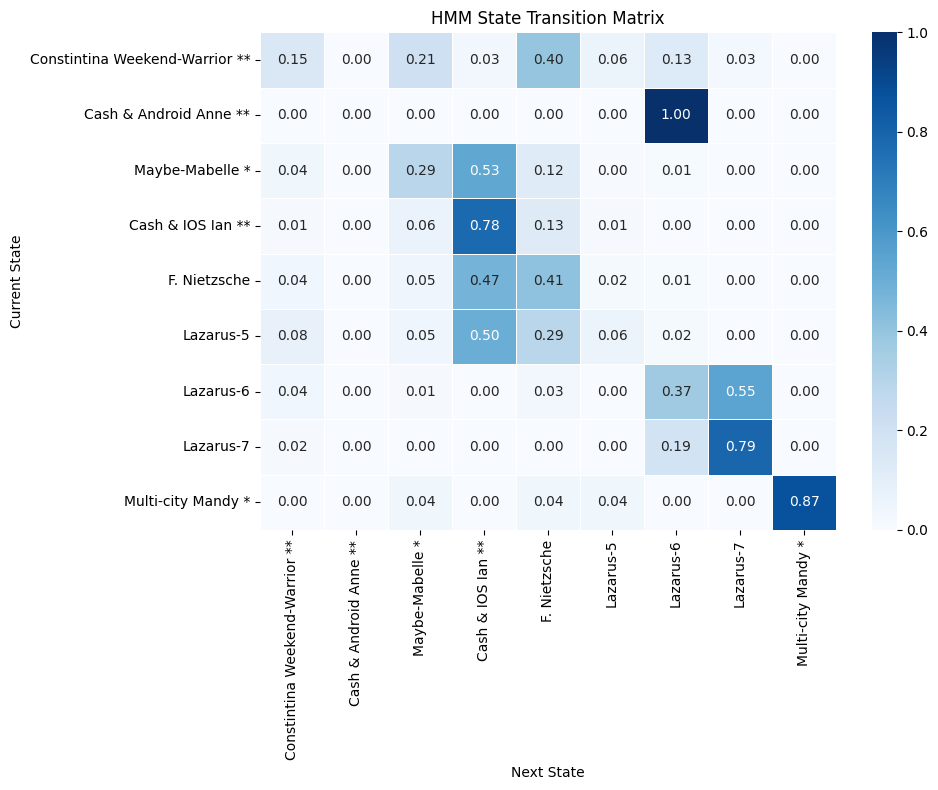

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace index and columns with custom state names
trans_df_named = trans_df.copy()
trans_df_named.index = state_names
trans_df_named.columns = state_names

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(trans_df_named, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("HMM State Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.show()


Model is not converging.  Current: 1242090.4117661354 is not greater than 1242090.9643415224. Delta is -0.5525753870606422
Model is not converging.  Current: 2302416.4125629277 is not greater than 2302416.4127508416. Delta is -0.00018791388720273972
Model is not converging.  Current: 2078879.7048292 is not greater than 2078879.7048293808. Delta is -1.809094101190567e-07
Model is not converging.  Current: 2338378.2533313734 is not greater than 2338378.310550404. Delta is -0.05721903033554554
Model is not converging.  Current: 2414781.386342198 is not greater than 2414781.3864478674. Delta is -0.00010566925629973412
Model is not converging.  Current: 2206929.5736812255 is not greater than 2206929.5740326783. Delta is -0.0003514527343213558


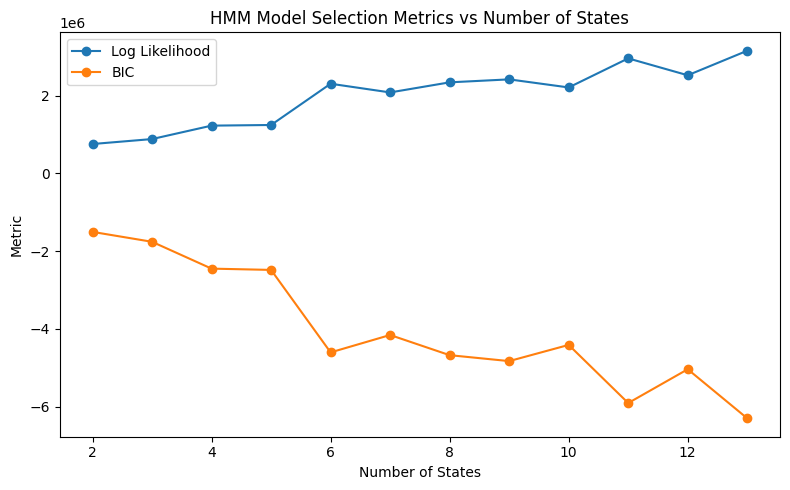

          log_likelihood           BIC
n_states                              
2           7.529807e+05 -1.505587e+06
3           8.804310e+05 -1.760258e+06
4           1.225497e+06 -2.450136e+06
5           1.242090e+06 -2.483045e+06
6           2.302416e+06 -4.603395e+06
7           2.078880e+06 -4.155996e+06
8           2.338373e+06 -4.674632e+06
9           2.414781e+06 -4.827074e+06
10          2.206930e+06 -4.410972e+06
11          2.954186e+06 -5.905062e+06
12          2.520129e+06 -5.036501e+06
13          3.151279e+06 -6.298330e+06


In [27]:
#TESTING the states

# 1. Prepare the data for HMM
df = X_final.dropna().sort_values(['passenger_id', 'week']).reset_index(drop=True)

# Observation matrix (N x D)
X_hmm = df[features_hmm].to_numpy()

# Sequence lengths per passenger
lengths = df.groupby('passenger_id').size().tolist()

# 2. Loop through different numbers of states
state_range = range(2, 14)
results = []

for n_states in state_range:
    model_test = GaussianHMM(
        n_components=n_states,
        covariance_type='diag',
        n_iter=200,
        random_state=202344,
        verbose=False
    )
    model_test.fit(X_hmm, lengths)

    if model_test.monitor_.converged:
        logL = model_test.score(X_hmm, lengths)
        n_features = X_hmm.shape[1]
        p = n_states * (n_states - 1) + (n_states - 1) + 2 * n_states * n_features
        bic = -2 * logL + p * np.log(X_hmm.shape[0])
        results.append({
            'n_states': n_states,
            'log_likelihood': logL,
            'BIC': bic
        })
    else:
        print(f"Model with {n_states} states did not converge.")

# 3. Compile and plot results
results_df = pd.DataFrame(results).set_index('n_states')

plt.figure(figsize=(8, 5))
plt.plot(results_df.index, results_df['log_likelihood'], marker='o', label='Log Likelihood')
plt.plot(results_df.index, results_df['BIC'], marker='o', label='BIC')
plt.xlabel('Number of States')
plt.ylabel('Metric')
plt.title('HMM Model Selection Metrics vs Number of States')
plt.legend()
plt.tight_layout()
plt.show()

print(results_df)


# Applying states to data from model above
(not the tuning):

In [30]:
state_sequence = model.predict(X_final[features_hmm])  
# Create a temporary series with the predictions aligned to X_final's index
hmm_state_series = pd.Series(state_sequence, index=X_final.index)
# Assign to weekly_data using loc to ensure proper alignment
weekly_data.loc[hmm_state_series.index, 'hmm_state'] = hmm_state_series


In [31]:
weekly_data.groupby('dead')['hmm_state'].value_counts() 

dead  hmm_state
0     3.0          94425
      4.0          27607
      7.0          23196
      2.0          12146
      6.0           8686
      0.0           4339
      5.0           2073
      8.0             24
1     3.0           2116
      4.0            617
      7.0            530
      2.0            288
      6.0            181
      0.0             87
      5.0             51
Name: count, dtype: int64

In [33]:
# Compute dominant state per passenger (most frequent hmm_state)
def get_dominant_state(x):
    """Get the most frequent hmm_state, handling empty/all-NaN cases."""
    value_counts = x.value_counts()
    if len(value_counts) > 0:
        return value_counts.idxmax()
    else:
        return np.nan

dominant_state = (
    weekly_data.groupby('passenger_id')['hmm_state']
    .apply(get_dominant_state)
    .rename('dominant_hmm_state')
    .reset_index()
)

# Merge back to weekly_data
weekly_data = weekly_data.merge(dominant_state, on='passenger_id', how='left')


In [ ]:
dominant_state.dominant_hmm_state.value_counts(normalize=False)


In [ ]:
def assign_dominant_state_names(weekly_df, state_names):
    """
    Adds a column to the DataFrame mapping dominant_hmm_state (int) to a name.

    Args:
        weekly_df (pd.DataFrame): Must contain 'dominant_hmm_state' column.
        state_names (list of str): List of state names, one for each HMM state.

    Returns:
        pd.DataFrame: Same as input, with new 'dominant_hmm_state_name' column.
    """
    if 'dominant_hmm_state' not in weekly_df.columns:
        raise ValueError("DataFrame must contain 'dominant_hmm_state' column.")

    max_index = max(weekly_df['dominant_hmm_state'])
    if max_index >= len(state_names):
        raise ValueError(f"state_names list is too short: expected at least {max_index + 1} entries.")

    state_map = dict(enumerate(state_names))
    weekly_df['dominant_hmm_state_name'] = weekly_df['dominant_hmm_state'].map(state_map)

    return weekly_df


In [ ]:
dominant_state = assign_dominant_state_names(dominant_state, state_names)
dominant_state.dominant_hmm_state_name.value_counts()

In [ ]:
len(dominant_state)